In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [83]:
df=pd.read_csv(r"C:\Users\adith\Downloads\archive (5)\Titanic-Dataset.csv")

In [84]:
df.columns=df.columns.str.strip()

In [85]:
sns.set_theme(style="whitegrid")

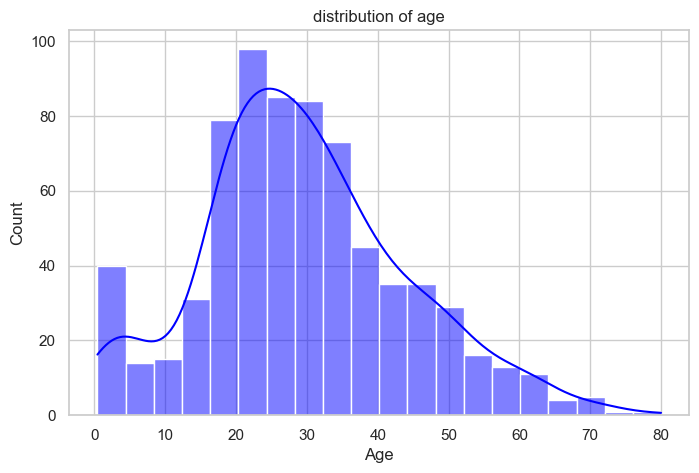

In [86]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"],bins=20,kde=True,color="blue")
plt.title("distribution of age")
plt.show()

In [87]:
def percentile(sorted_vals, p):
    idx = p * (len(sorted_vals) - 1)
    lower_idx = int(idx)
    upper_idx = lower_idx + 1
    frac = idx - lower_idx
    if upper_idx >= len(sorted_vals):
        return sorted_vals[lower_idx]
    return sorted_vals[lower_idx] + frac * (sorted_vals[upper_idx] - sorted_vals[lower_idx])
def find_outliers_iqr(data, col):
    values = sorted(data[col].dropna().tolist())
    q1 = percentile(values, 0.25)
    q3 = percentile(values, 0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (data[col] < lower) | (data[col] > upper)
    return data.loc[mask], lower, upper



In [88]:
numeric_cols = ["Age", "Fare", "SibSp", "Parch"]

print("\n" + "=" * 60)
print("IQR OUTLIERS")
print("=" * 60)
for col in numeric_cols:
    outliers, lower, upper = find_outliers_iqr(df, col)
    print(f"\n[{col}]  valid range: {lower:.2f} to {upper:.2f}  "
          f"| {len(outliers)} outliers out of {df[col].notna().sum()} values")
    if not outliers.empty:
        cols_to_show = ["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch", "Survived"]
        print(outliers[cols_to_show].head(10).to_string(index=False))


IQR OUTLIERS

[Age]  valid range: -6.69 to 64.81  | 11 outliers out of 714 values
 Pclass  Sex  Age    Fare  SibSp  Parch  Survived
      2 male 66.0 10.5000      0      0         0
      1 male 65.0 61.9792      0      1         0
      1 male 71.0 34.6542      0      0         0
      3 male 70.5  7.7500      0      0         0
      3 male 65.0  7.7500      0      0         0
      1 male 65.0 26.5500      0      0         0
      1 male 71.0 49.5042      0      0         0
      1 male 80.0 30.0000      0      0         1
      2 male 70.0 10.5000      0      0         0
      1 male 70.0 71.0000      1      1         0

[Fare]  valid range: -26.72 to 65.63  | 116 outliers out of 891 values
 Pclass    Sex  Age     Fare  SibSp  Parch  Survived
      1 female 38.0  71.2833      1      0         1
      1   male 19.0 263.0000      3      2         0
      1 female  NaN 146.5208      1      0         1
      1   male 28.0  82.1708      1      0         0
      1 female 49.0  76.7292  

C:\Users\adith\AppData\Local\Temp\ipykernel_8440\1327827344.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x="Pclass",y="Fare",palette="viridis")


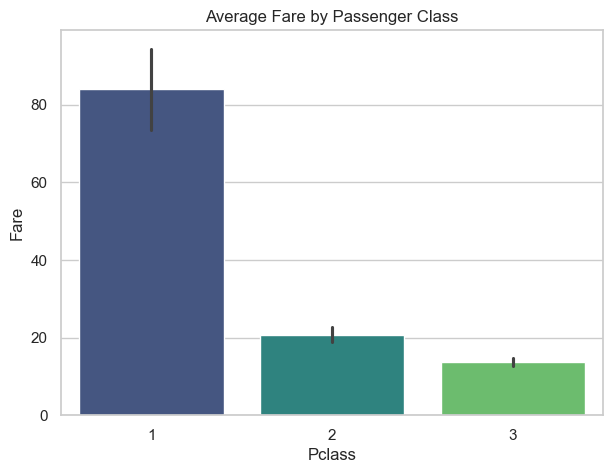

In [89]:
plt.figure(figsize=(7,5))
sns.barplot(data=df,x="Pclass",y="Fare",palette="viridis")
plt.title("Average Fare by Passenger Class")
plt.show()

C:\Users\adith\AppData\Local\Temp\ipykernel_8440\1671011104.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x="Sex",y="Survived",palette="viridis")


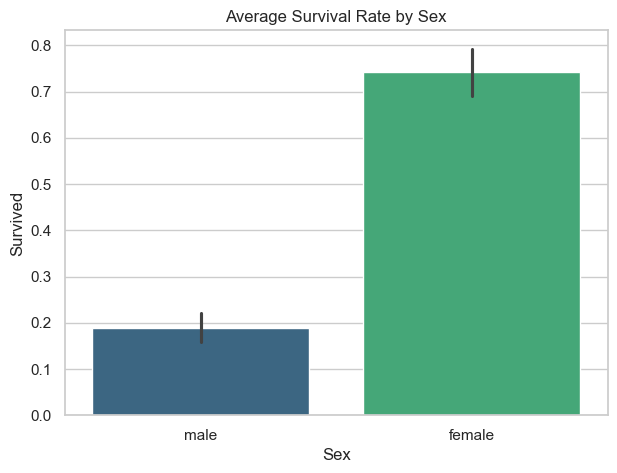

In [90]:
plt.figure(figsize=(7,5))
sns.barplot(data=df,x="Sex",y="Survived",palette="viridis")
plt.title("Average Survival Rate by Sex")
plt.show()


C:\Users\adith\AppData\Local\Temp\ipykernel_8440\760893896.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x="Pclass",y="Survived",palette="viridis")


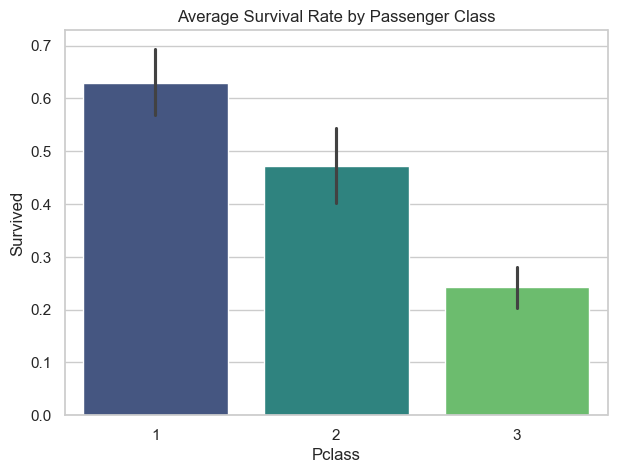

In [91]:
plt.figure(figsize=(7,5))
sns.barplot(data=df,x="Pclass",y="Survived",palette="viridis")
plt.title("Average Survival Rate by Passenger Class")
plt.show()

C:\Users\adith\AppData\Local\Temp\ipykernel_8440\2150537415.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Sex", palette="viridis")


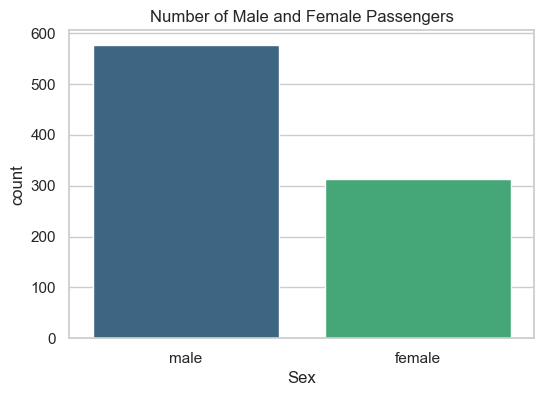

In [92]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Sex", palette="viridis")
plt.title("Number of Male and Female Passengers")
plt.show()

C:\Users\adith\AppData\Local\Temp\ipykernel_8440\1778645625.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Pclass", palette="viridis")


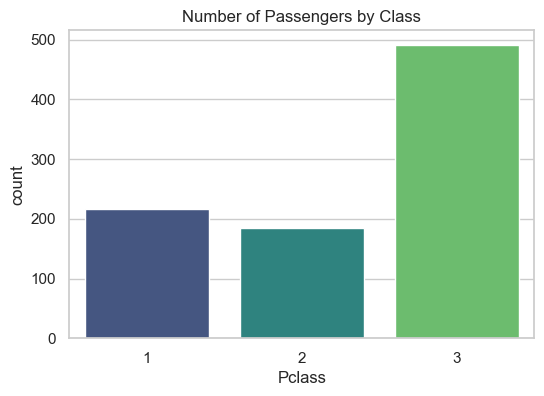

In [93]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Pclass", palette="viridis")
plt.title("Number of Passengers by Class")
plt.show()

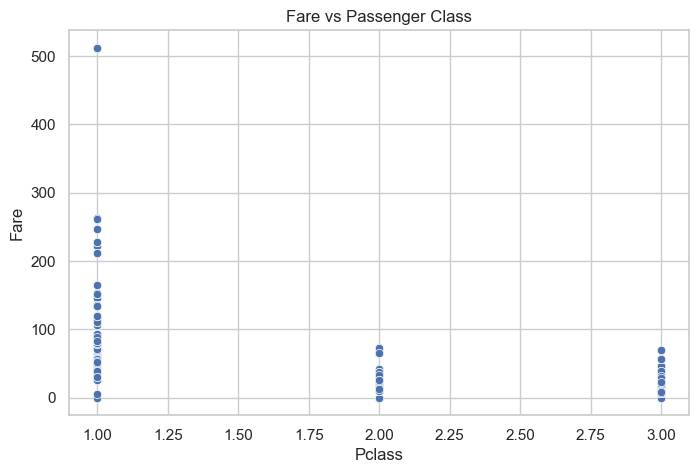

In [94]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="Pclass",y="Fare")
plt.title("Fare vs Passenger Class")
plt.show()

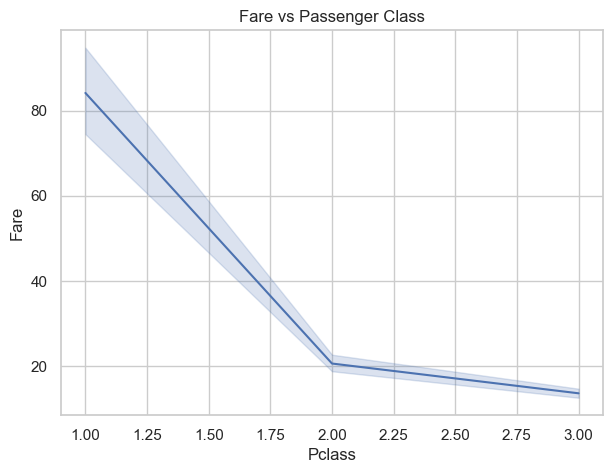

In [95]:
plt.figure(figsize=(7,5))
sns.lineplot(data=df,x="Pclass",y="Fare")
plt.title("Fare vs Passenger Class")
plt.show()

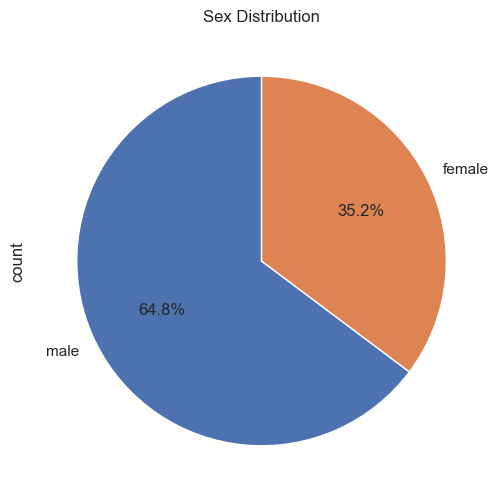

In [96]:
column="Sex"
plt.figure(figsize=(6,6))
df[column].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title(f"{column} Distribution")
plt.show()

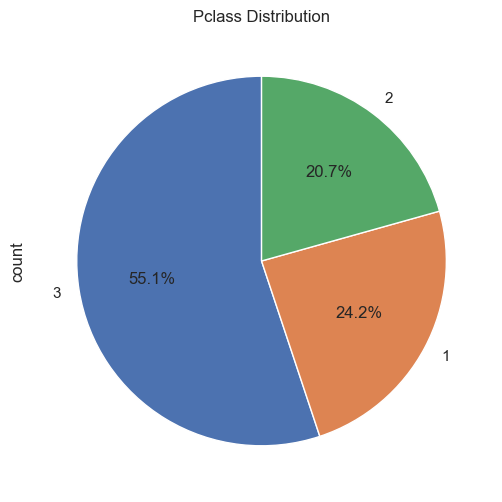

In [97]:
column="Pclass"
plt.figure(figsize=(6,6))
df[column].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title(f"{column} Distribution")
plt.show()

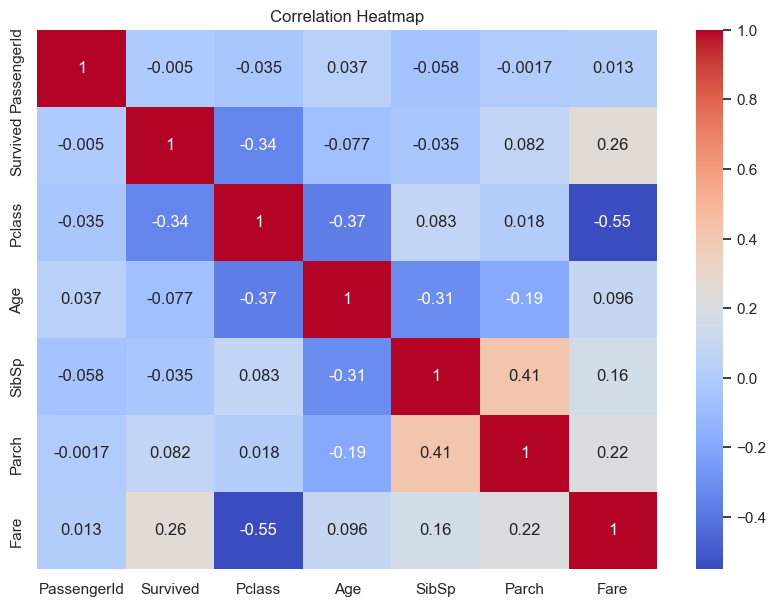

In [98]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [99]:
print(df.head(10))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54

In [100]:
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [101]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


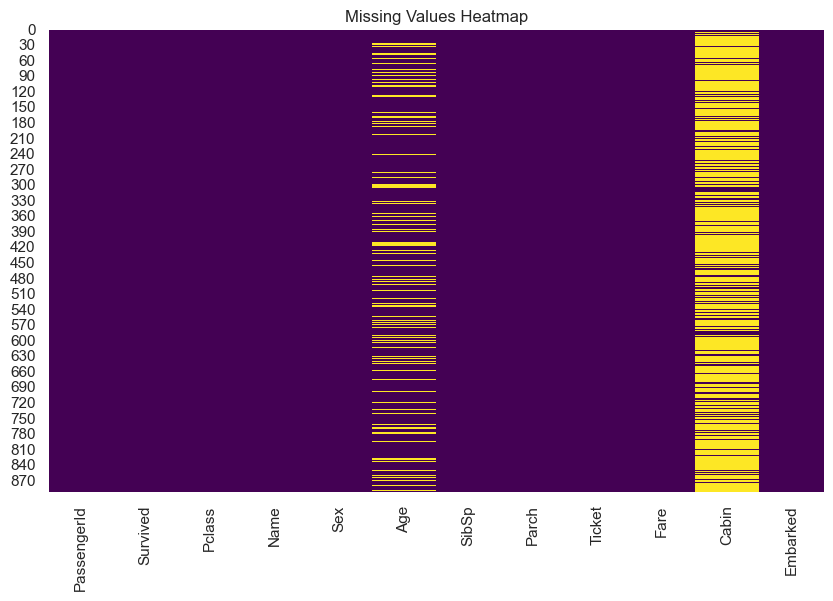

In [102]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [103]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [104]:
missing_percentage=(df.isnull().sum()/len(df))*100
print(missing_percentage)

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [105]:
age_median = df["Age"].median()
df["Age"] = df["Age"].fillna(age_median)
df["Age"].isnull()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Name: Age, Length: 891, dtype: bool

In [106]:
df["Age"].isnull().sum()

np.int64(0)

In [107]:
remove_cols=["Cabin"]

In [108]:
embarked_mode = df["Embarked"].mode()
df["Embarked"] = df["Embarked"].fillna(embarked_mode)
df["Embarked"].isnull().count

<bound method Series.count of 0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Name: Embarked, Length: 891, dtype: bool>

In [109]:
duplicate_rows = df.duplicated()
remove_duplicates = df.drop_duplicates()
print(f"Number of duplicate rows: {duplicate_rows.sum()}")

Number of duplicate rows: 0


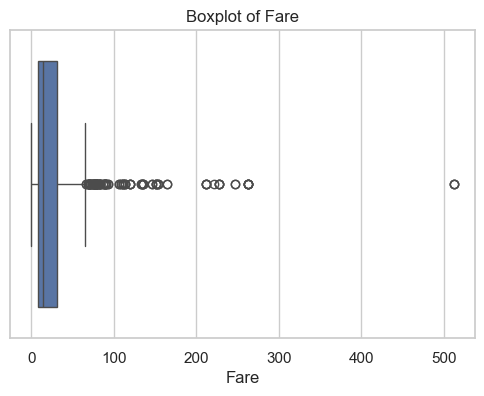

In [110]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Fare"])
plt.title("Boxplot of Fare")
plt.show()

In [115]:
df.to_csv("Titanic-Dataset-Cleaned.csv", index=False)

In [111]:
sex_unique=df["Sex"].unique()
print(sex_unique)

['male' 'female']


In [112]:
df=df.drop(columns=["PassengerId","Name","Ticket"])
print(df.head())

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Cabin Embarked
0         0       3    male  22.0      1      0   7.2500   NaN        S
1         1       1  female  38.0      1      0  71.2833   C85        C
2         1       3  female  26.0      0      0   7.9250   NaN        S
3         1       1  female  35.0      1      0  53.1000  C123        S
4         0       3    male  35.0      0      0   8.0500   NaN        S


In [113]:

    q1 = df["Fare"].quantile(0.25)
    q3 = df["Fare"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df["Fare"] >=lower) & (df["Fare"] <= upper)

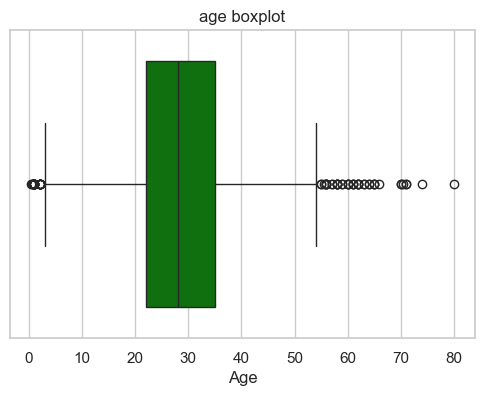

In [114]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Age"],color="green")
plt.title("age boxplot")
plt.show()